In [1]:
!pip install -q git+https://github.com/huggingface/diffusers
!pip install transformers accelerate datasets torchvision
!pip install bitsandbytes

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.6 MB/s eta 0:00:00


In [2]:
import diffusers
print(diffusers.__version__)

0.38.0.dev0


In [3]:
!git clone https://github.com/huggingface/diffusers.git
%cd diffusers/examples/text_to_image

Cloning into 'diffusers'...
remote: Enumerating objects: 119097, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 119097 (delta 82), reused 49 (delta 49), pack-reused 118991 (from 2)
Receiving objects: 100% (119097/119097), 91.85 MiB | 36.02 MiB/s, done.
Resolving deltas: 100% (89017/89017), done.
/content/diffusers/examples/text_to_image


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/897 [00:00<?, ?B/s]

data/train-00000-of-00002-12944970063701(…):   0%|          | 0.00/344M [00:00<?, ?B/s]

data/train-00001-of-00002-cefa2f480689f1(…):   0%|          | 0.00/357M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1221 [00:00<?, ? examples/s]

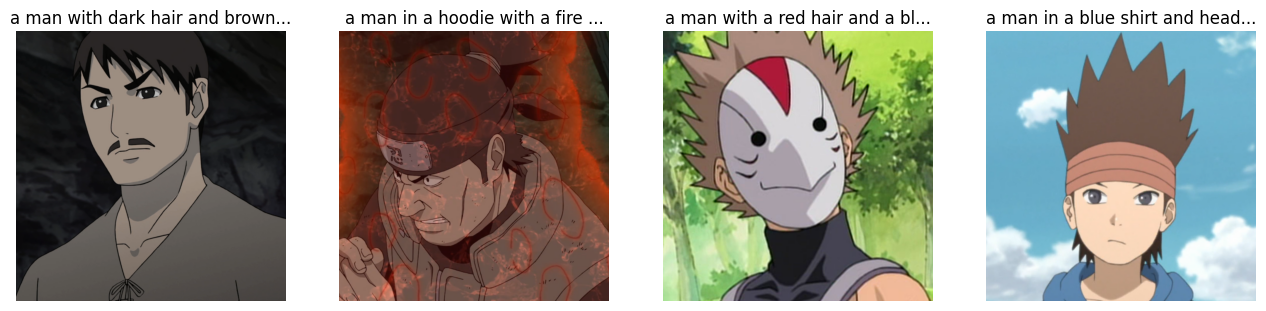

In [4]:
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset("lambdalabs/naruto-blip-captions", split="train")

# Show 4 samples
fig, axes = plt.subplots(1, 4, figsize=(16,4))

for i in range(4):
    img = dataset[i]["image"]
    caption = dataset[i]["text"]

    axes[i].imshow(img)
    axes[i].set_title(caption[:30] + "...")
    axes[i].axis("off")

plt.show()

In [5]:
import torch
print("GPU:", torch.cuda.get_device_name(0))

GPU: NVIDIA A100-SXM4-40GB


In [6]:
!accelerate config default

accelerate configuration saved at /root/.cache/huggingface/accelerate/default_config.yaml


In [ ]:
from huggingface_hub import login
login("your_huggingface_token_here")

In [8]:
!accelerate launch train_text_to_image.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --dataset_name="lambdalabs/naruto-blip-captions" \
  --use_ema \
  --resolution=512 --center_crop --random_flip \
  --train_batch_size=2 \
  --gradient_accumulation_steps=2 \
  --gradient_checkpointing \
  --mixed_precision="fp16" \
  --max_train_steps=15000 \
  --learning_rate=1e-05 \
  --max_grad_norm=1 \
  --lr_scheduler="constant" --lr_warmup_steps=0 \
  --checkpointing_steps=3000 \
  --logging_dir="sd-naruto-model/logs" \
  --output_dir="sd-naruto-model"

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
INFO:__main__:[RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
INFO:httpx:HTTP Request: HEAD https://huggingface.co/runwayml/stable-diffusion-v1-5/resolve/main/scheduler/scheduler_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5/resolve/main/s

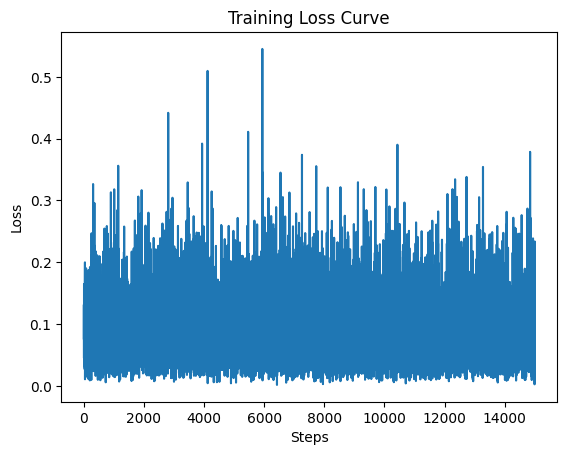

In [11]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

log_dir = "/content/diffusers/examples/text_to_image/sd-naruto-model/sd-naruto-model/logs/text2image-fine-tune"

ea = event_accumulator.EventAccumulator(log_dir)
ea.Reload()

loss = ea.Scalars("train_loss")

steps = [x.step for x in loss]
values = [x.value for x in loss]

plt.plot(steps, values)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

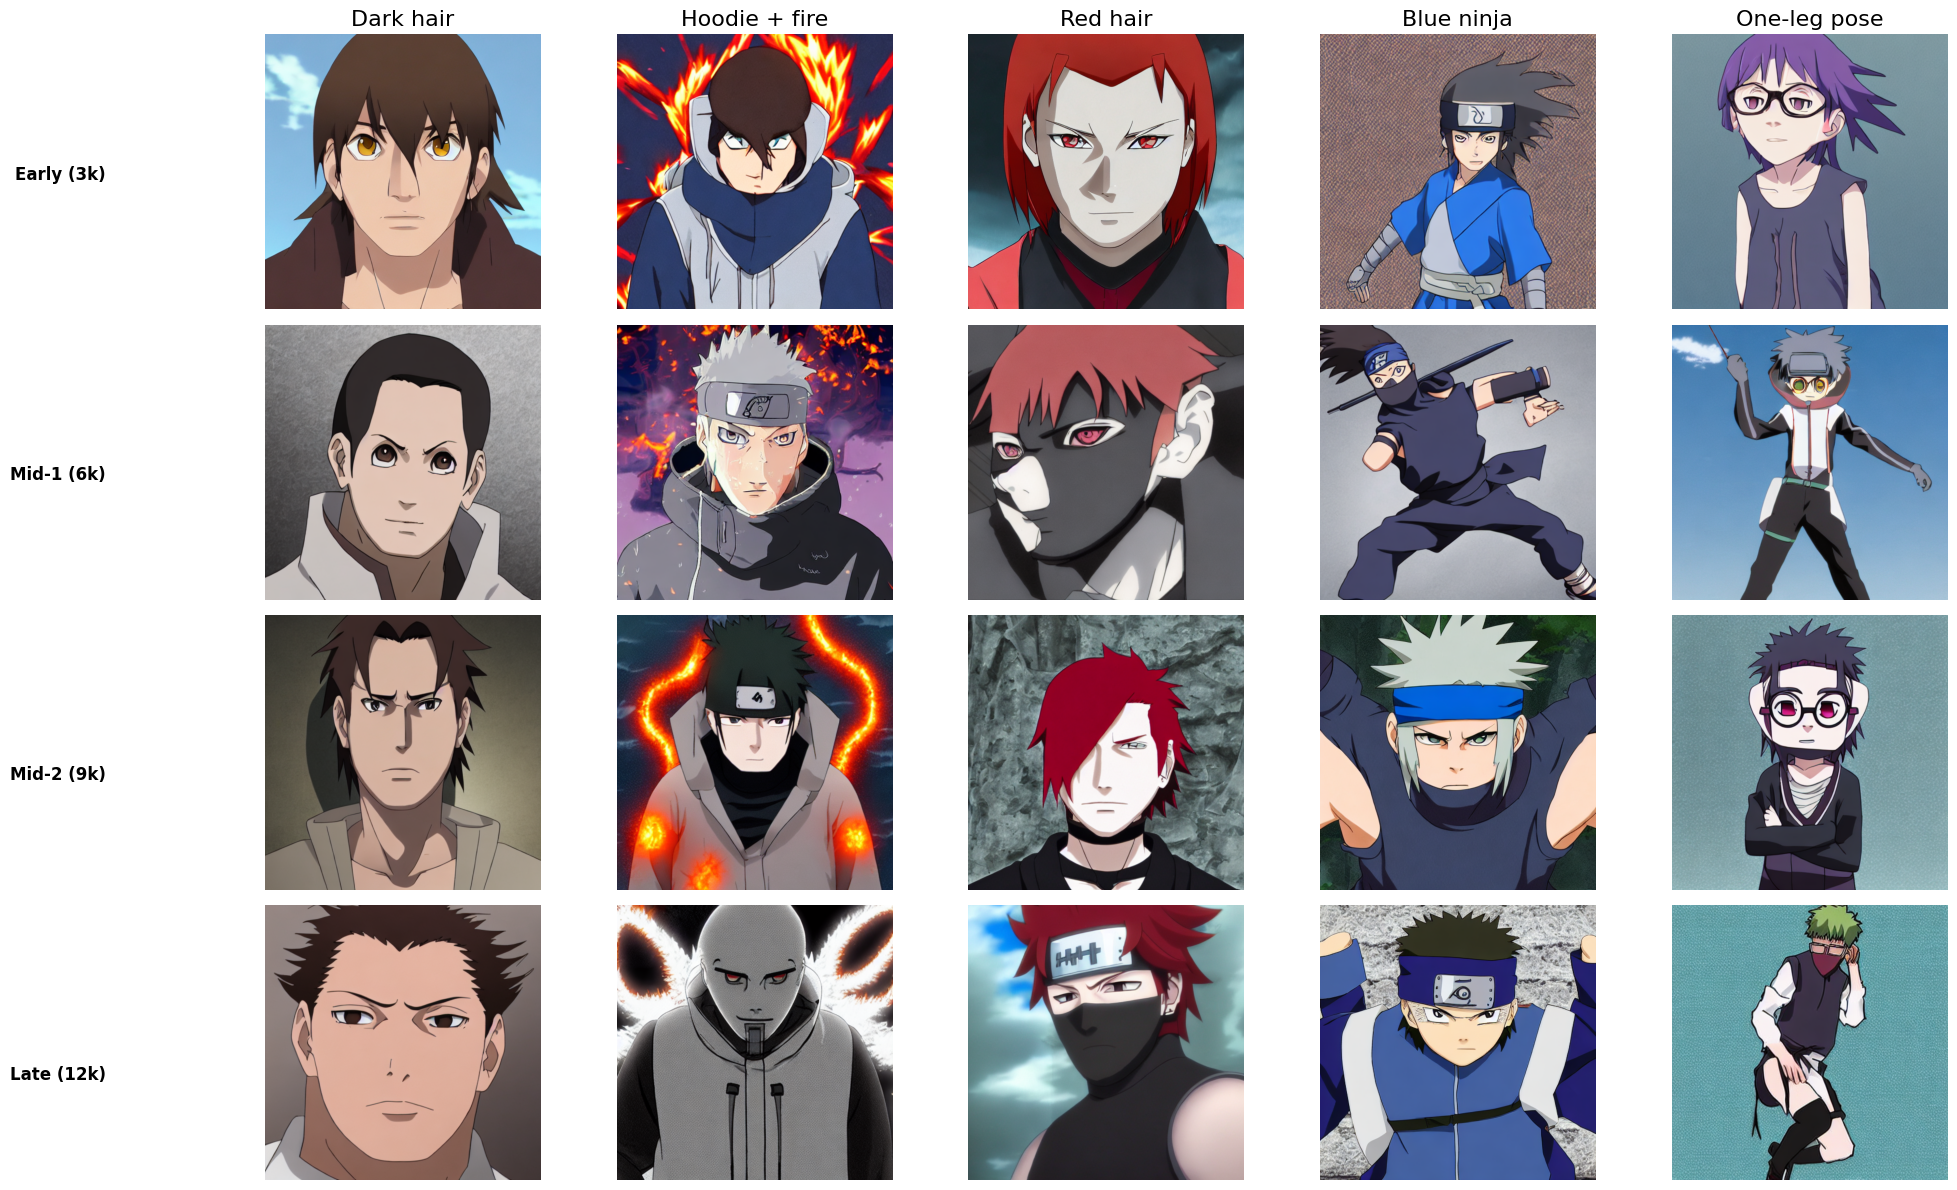

In [23]:
from diffusers import StableDiffusionPipeline, UNet2DConditionModel
from safetensors.torch import load_file
import torch
import matplotlib.pyplot as plt

output_dir = "sd-naruto-model"

checkpoint_steps = [3000, 6000, 9000, 12000]

# Better readable labels
checkpoint_labels = [
    "Early (3k)",
    "Mid-1 (6k)",
    "Mid-2 (9k)",
    "Late (12k)"
]

prompts = [
    "portrait of a man with dark hair and brown eyes, anime style, ultra detailed, soft lighting",
    "anime man in hoodie, fire background, dramatic lighting, cinematic, high detail",
    "red haired anime man wearing black shirt, sharp features, detailed face",
    "anime ninja wearing blue shirt and headband, dynamic pose, high detail",
    "anime character with glasses balancing on one leg, full body"
]

prompts_short = [
    "Dark hair",
    "Hoodie + fire",
    "Red hair",
    "Blue ninja",
    "One-leg pose"
]

# Load pipeline ONCE
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    safety_checker=None
).to("cuda")

all_images = []

for step in checkpoint_steps:
    ckpt_path = f"{output_dir}/checkpoint-{step}/unet"

    unet = UNet2DConditionModel.from_config(pipe.unet.config)
    state_dict = load_file(f"{ckpt_path}/diffusion_pytorch_model.safetensors")
    unet.load_state_dict(state_dict)

    pipe.unet = unet.to("cuda", dtype=torch.float16)

    row_images = []
    for prompt in prompts:
        image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]
        row_images.append(image)

    all_images.append(row_images)

# 🔥 Plot with labels
fig, axes = plt.subplots(len(checkpoint_steps), len(prompts), figsize=(20,12))

for i in range(len(checkpoint_steps)):
    for j in range(len(prompts)):
        axes[i, j].imshow(all_images[i][j])

        # Top row → prompt titles
        if i == 0:
            axes[i, j].set_title(prompts_short[j], fontsize=16)

        axes[i, j].axis("off")

# 🔥 Add row labels manually (left side, clearly visible)
for i, label in enumerate(checkpoint_labels):
    fig.text(
        0.04,                          # x position (left margin)
        0.85 - i * (1 / len(checkpoint_steps)),  # y position
        label,
        va='center',
        ha='right',
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout(rect=[0.08, 0, 1, 1])  # leave space on left
plt.show()

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

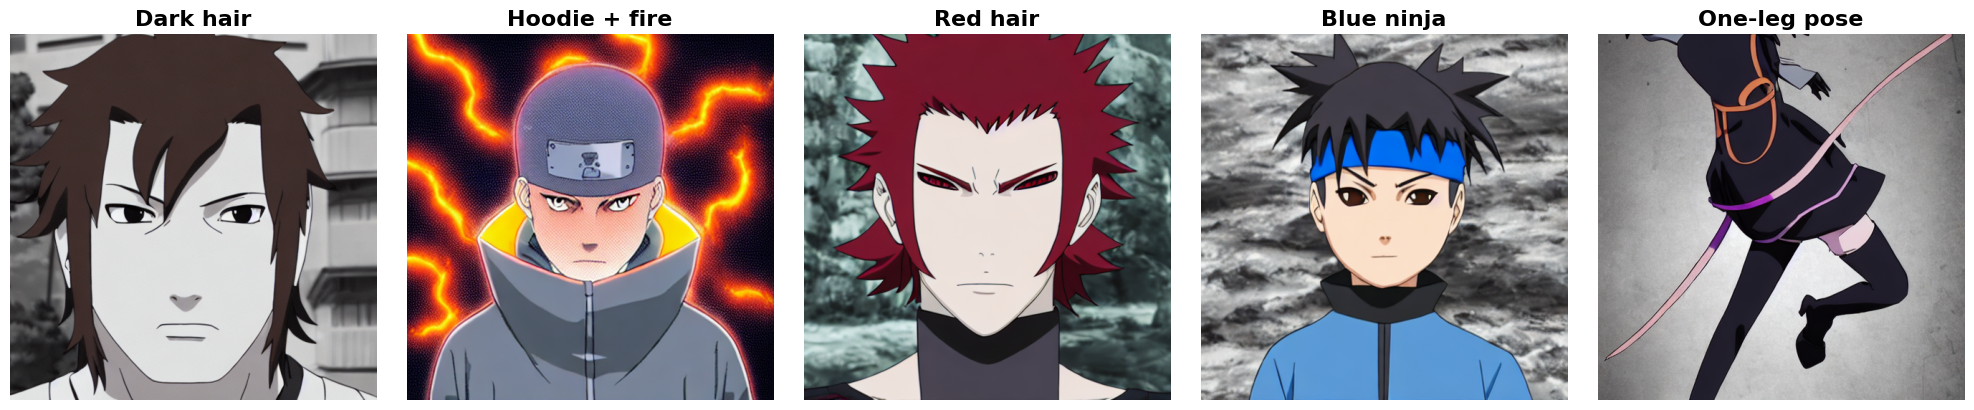

In [25]:
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt

pipe = StableDiffusionPipeline.from_pretrained(
    "sd-naruto-model",
    torch_dtype=torch.float16,
    safety_checker=None
).to("cuda")

prompts = [
    "portrait of a man with dark hair and brown eyes, anime style, ultra detailed",
    "anime man in hoodie, fire background, dramatic lighting",
    "red haired anime man wearing black shirt",
    "anime ninja wearing blue shirt and headband",
    "anime character with glasses balancing on one leg, full body"
]

prompts_short = [
    "Dark hair",
    "Hoodie + fire",
    "Red hair",
    "Blue ninja",
    "One-leg pose"
]

# Generate images
images = []
for prompt in prompts:
    image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]
    images.append(image)

# Plot grid (correct way)
fig, axes = plt.subplots(1, len(images), figsize=(20,4))

for i, img in enumerate(images):
    axes[i].imshow(img)
    axes[i].set_title(prompts_short[i], fontsize=16, fontweight='bold')
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# Save individual images
for i, img in enumerate(images):
    img.save(f"final_output_{prompts_short[i].replace(' ', '_')}.png")

# ✅ Save full grid properly
fig.savefig("final_outputs_grid.png", dpi=300, bbox_inches="tight")